# Word Embeddings - CBOW and SkipGram Architecture

**You shall know the word by the company it keeps** - If a machine can predict the words from their context, then it would have captured the meaning of the word

### Intuition

**Capturing Meaning via Prediction:** Imagine teaching a machine to understand language by making it guess missing words based on the words around them. If the machine can accurately predict the missing word, it reveals it's grasped the word’s meaning through its context. This core idea forms the foundation of modern word embeddings, where meaning is learned not just from the word itself, but from how it appears alongside others.

#### Step 1: Neural Network Predicts a Word from Surrounding Words

Consider the sentence:

> “A quick brown ___ jumps over the lazy dog.”

The machine’s task is to predict the missing word “fox” by looking at the context words: “A quick brown” and “jumps over the lazy dog.”

Similarly, for the phrase:

> “Reading helps to expand your ___.”

The model predicts the word “mind” given the neighbors “Reading helps to expand your” and “to expand your ___.”

In the training phase, many such contexts and target pairs are fed to a neural network to learn this prediction task.

#### Step 2: Training the Model

The neural network starts untrained and guesses randomly. Over time, it adjusts its parameters to increase the probability of the correct target words for their contexts.

For example, early on, the model might guess the word “box” for

> “A quick brown ___ jumps...”

but after seeing many examples, it gradually learns “fox” is much more likely.

Through many such examples, the model steadily improves predictions.

#### Step 3: Extracting What the Model Has Learned











Here’s the surprising twist: While the network's ability to predict words is valuable, what holds the real treasure is **not the output predictions themselves**.

Instead, the rich knowledge lies in the neural network’s **internal parameters**, specifically the weight matrices connecting the input and projection layers.

These matrices contain **dense vector representations** for each word—known as **word embeddings**—which encode semantic and syntactic information learned by observing contexts.


### Skip-Gram vs CBOW

#### Skip-Gram Model

- **Objective**: Given a **single input word**, predict the words that occur within a predefined window before and after it.

- **Example**: For the sentence  
  *“All that glitters is not gold”*  
  If the input word is **“glitters”**, the model tries to predict surrounding words like **“that”**, **“is”**, etc.

- Skip-Gram focuses on learning the representation of the input word by trying to predict its neighboring words.

- This approach works well with smaller datasets and is effective for capturing representations of **rare words**.

#### Continuous Bag of Words (CBOW) Model

- **Objective**: Given the **surrounding context words**, predict the **center (middle) word**.

- **Example**: For the sentence  
  *“All that glitters is not gold”*  
  If the input words are **“All”**, **“that”**, **“is”**, and **“not”**, the model tries to predict the center word **“glitters”**.

- CBOW aggregates the context vectors (usually by averaging) and uses that to predict the missing word.

- CBOW is generally faster and works well for larger datasets.

| Model      | Input                      | Output                      | Purpose                |
|------------|----------------------------|-----------------------------|------------------------|
| Skip-Gram  | Single center word          | Words in surrounding window | Predict context words   |
| CBOW       | Multiple surrounding words  | Single center word           | Predict center word     |


- **Skip-Gram** predicts the context from a word; good for rare words and small corpora.  
- **CBOW** predicts the word from its context; faster, works better on large corpora.  

Both learn word embeddings by leveraging the principle that context defines meaning, just reversing the input-output relationship for prediction.


### CBOW Training Data

**Input Sentence**:  
*"Fresh ripe strawberries grow best in sunny fields."*

**Configuration**:
- **Vocabulary**: {fresh, ripe, strawberries, grow, best, in, sunny, fields} → **8 unique words** (V=8)
- **Context Window**: **1** (1 word before + 1 word after target word)

#### Window-Based Training Sample Creation

```
Position 1: "Fresh ripe strawberries..."
Left: [∅]        Target: "fresh"     → Skip (insufficient left context)
Position 2: "Fresh ripe strawberries..."
Left: [fresh]     Right: [strawberries]  Target: "ripe"
Position 3: "ripe strawberries grow..."
Left: [fresh, ripe] Right: [grow]     Target: "strawberries"
...
```

#### Training Examples Table

| **Target Word** | **Left Context** | **Right Context** | **Combined Context (X)** | **Target Label (Y)** |
|-----------------|------------------|-------------------|--------------------------|---------------------|
| ripe            | fresh            | strawberries      | [fresh, strawberries]    | ripe                |
| strawberries    | ripe             | grow              | [ripe, grow]             | strawberries        |
| grow            | strawberries     | best              | [strawberries, best]     | grow                |
| best            | grow             | in                | [grow, in]               | best                |
| in              | best             | sunny             | [best, sunny]            | in                  |
| sunny           | in               | fields            | [in, fields]             | sunny               |
| fields          | sunny            | ∅                 | [sunny]                  | fields              |

#### Training Dataset

```
X_train (Context Sequences):
[
  [fresh_idx, strawberries_idx],   # → Predict: ripe
  [ripe_idx, grow_idx],            # → Predict: strawberries
  [strawberries_idx, best_idx],    # → Predict: grow
  [grow_idx, in_idx],              # → Predict: best
  [best_idx, sunny_idx],           # → Predict: in
  [in_idx, fields_idx],            # → Predict: sunny
  [sunny_idx, PAD_idx]             # → Predict: fields
]

Y_train (Target Indices):
[ripe_idx, strawberries_idx, grow_idx, best_idx, in_idx, sunny_idx, fields_idx]
```

**Final Dimensions**:
```
X_train: [7 examples × 2 contexts] → Padded to [7, 2]
Y_train: [7 examples] → [7]
```

**Network Flow**
```
Input Context: [fresh, strawberries]
↓
Embedding Lookup: C[fresh], C[strawberries]
↓
Vector Averaging: (C[fresh] + C[strawberries]) / 2 → [emb_dim]
↓
Linear Layer → Softmax(V) → P(ripe | context)
```

**Impact of Context Window Size**

```
Window=1: [left1, right1] → Local relationships, fast training
Window=2: [left2,left1,right1,right2] → Broader context, richer semantics
Window=3: Even more context → Slower, more computationally expensive
```

**Vocabulary Mapping**:
```
fresh=1, ripe=2, strawberries=3, grow=4, best=5, in=6, sunny=7, fields=8
Example: X[0] = [1, 3] → Predict Y[0] = 2 (ripe)
```

### Do Words Enter into Neural Networks Directly?

**Example Sentence**: *"Fresh ripe strawberries grow best in sunny fields."*

**Context Window = 1** → **Training Samples**:

| Target Word    | Context Input (X)         | Target Output (Y) |
|----------------|---------------------------|-------------------|
| ripe           | [fresh, strawberries]     | ripe              |
| strawberries   | [ripe, grow]              | strawberries      |
| grow           | [strawberries, best]      | grow              |
| best           | [grow, in]                | best              |
| in             | [best, sunny]             | in                |
| sunny          | [in, fields]              | sunny             |
| fields         | [sunny]                   | fields            |

```
X_train Shape: [7 samples × 2 contexts]
Y_train Shape: [7 targets]
```

#### Solution: One-Hot Encoding

**Vocabulary** (V=8): {fresh=0, ripe=1, strawberries=2, grow=3, best=4, in=5, sunny=6, fields=7}

**One-Hot Conversion**

```
fresh → [1,0,0,0,0,0,0,0]
ripe  → [0,1,0,0,0,0,0,0]  
strawberries → [0,0,1,0,0,0,0,0]
```

**First Training Sample**:
```
Context: [fresh, ripe] → Target: strawberries

X[0] One-Hot Matrix:
[[1,0,0,0,0,0,0,0],    # fresh
 [0,1,0,0,0,0,0,0]]    # ripe
Shape: [2 contexts × 8 vocab]

Y[0] One-Hot: [0,0,1,0,0,0,0,0]  # strawberries
```

**Complete CBOW Training Data (One-Hot Format)**

```
X_train_onehot = [
  [[1,0,0,0,0,0,0,0], [0,0,1,0,0,0,0,0]],  # fresh, strawberries → ripe
  [[0,1,0,0,0,0,0,0], [0,0,0,1,0,0,0,0]],  # ripe, grow → strawberries
  # ... 5 more samples
]

Y_train_onehot = [
  [0,1,0,0,0,0,0,0],  # ripe
  [0,0,1,0,0,0,0,0],  # strawberries
  # ... 5 more targets
]
```

**Neural Network Processing Pipeline**

```
Raw Words → Indices → One-Hot → Embedding Lookup → Dense Vectors
   ↓          ↓         ↓             ↓              ↓
["fresh"]  [0]    [1,0,0...]   C[0]     [0.2,-0.1,0.8]
["ripe"]   [1]    [0,1,0...]   C[1]     [-0.3,0.4,-0.2]

Average: [-0.05, 0.15, 0.3] → Feed to Dense → Softmax(V) → P(target)
```

### CBOW Model Architecture

**Strawberries Vocabulary** (V=8): {fresh, ripe, strawberries, grow, best, in, sunny, fields}

**Layer Configuration**:
- **Input**: 8 neurons (one-hot encoded context words)
- **Hidden**: 4 neurons (embedding dimension - **configurable**!)
- **Output**: 8 neurons (vocabulary probability distribution)

#### Simple Feedforward Network (single hidden layer)

```
Input Layer          → Hidden Layer → Output Layer
[Vocab Size=8]         [Embedding Dim=4]  [Vocab Size=8]
One-Hot Context        Linear Act.       Softmax Act.
```

**Weight Matrices Structure**

```
W1 ∈ ℝ^(8 × 4) = Input → Hidden (EMBEDDING MATRIX!)
• Row 0: fresh embedding, Row 1: ripe embedding, etc.

W2 ∈ ℝ^(4 × 8) = Hidden → Output projection
```

**Training Example: Predicting "ripe"**

**Training Pair**: Context = ["fresh", "strawberries"] → Target = "ripe"

**Step 1: One-Hot Encoding**
```
Vocabulary indices: fresh=0, ripe=1, strawberries=2, grow=3, best=4, in=5, sunny=6, fields=7

fresh (idx=0): [1,0,0,0,0,0,0,0]
strawberries (idx=2): [0,0,1,0,0,0,0,0]

X_input = [[1,0,0,0,0,0,0,0],    # fresh
           [0,0,1,0,0,0,0,0]]    # strawberries
Shape: [2 contexts × 8 vocab]
```

**Step 2: Hidden Layer – Average Embedding Projection**

```
Hidden Layer Output (h_hidden):
h_hidden = (fresh_embedding + strawberries_embedding) / 2
        = (W1[0,:] + W1[2,:]) / 2
        = Average context embeddings!

Example Values:
fresh_embedding     = [0.2, -0.1, 0.8, 0.3]
strawberries_emb    = [-0.4, 0.6, -0.2, 0.1]
h_hidden            = [-0.1, 0.25, 0.3, 0.2]  # Averaged!

Shape: [1 × 4]  # 4D latent representation
Activation: Linear
```

**Step 3: Output Layer – Softmax Classification**

```
Output Logits:
logits = h_hidden × W2 = [-0.1, 0.25, 0.3, 0.2] × W2[4×8]
Shape: [1 × 8]  # Raw scores for vocab

Final Probabilities:
P(vocab | ["fresh", "strawberries"]) = softmax(logits)
```

**Target Goal**:
```
P(ripe | context) = 0.89  # Highest!
P(fresh)=0.02, P(strawberries)=0.03, P(grow)=0.04, etc.
```

**Complete Forward Pass Visualization**

```
["fresh", "strawberries"]
     ↓ One-Hot [2×8]
W1 [8×4] ← Average Embeddings
     ↓ [1×4] Linear
W2 [4×8] → Softmax → [1×8] P(vocab)
                ↑
      Target: ripe (idx=1)
```

**Softmax Distribution**:
```
[fresh:0.02, ripe:0.89, strawberries:0.03, grow:0.04, best:0.01, in:0.005, sunny:0.01, fields:0.015]
                     ↑ Peak at target!
```

#### Backpropagation

**Loss Computation**
```
Predicted Output: P(ripe) = 0.89
Actual Target: ripe (one-hot [0,1,0,0,0,0,0,0])

CrossEntropy Loss:
L = -log[P(ripe | context)] = -log(0.89) ≈ 0.12

Goal: Minimize L across ALL training samples!
```

**Gradient Flow Through Network**
```
Loss L → ∂L/∂W2 → ∂L/∂h_hidden → ∂L/∂W1
              ↓
        Update ALL weights simultaneously!
```

**Weight Updates** (Gradient Descent):
```
W1_new = W1_old - η × ∂L/∂W1  # fresh, strawberries embeddings updated!
W2_new = W2_old - η × ∂L/∂W2
```

#### Full Training



**Complete Dataset** (from previous lecture):
```
1. ["fresh", "strawberries"] → ripe
2. ["ripe", "grow"] → strawberries
3. ["strawberries", "best"] → grow
4. ["grow", "in"] → best
5. ["best", "sunny"] → in
6. ["in", "fields"] → sunny
7. ["sunny"] → fields
```

**Training Loop**:
```
Epoch 1:
  Sample 1 → Forward → Loss1 → Backprop → Update W1,W2
  Sample 2 → Forward → Loss2 → Backprop → Update W1,W2  
  ...
  Sample 7 → Forward → Loss7 → Backprop → Update W1,W2

Epoch 2: Repeat for all 7 samples...
```

**Cumulative Effect**:
```
After 100 epochs:
• W1[fresh] ≈ semantic vector for "fresh"
• W1[ripe] ≈ semantic vector for "ripe"
• W1[strawberries] clusters with "fields", "grow"
```

### Word Embeddings from Weight Matrices

#### The Big Question: Why Predict Words If We Want Embeddings?

```
Common Misunderstanding:
"We train CBOW → Predict words → Use predictions for NLP?"

Reality:
- IGNORE predictions! (They're just training signal)
- EXTRACT learned weights! (They contain semantics)

Training Purpose: Force network to learn meaningful representations
Goldmine Location: WEIGHT MATRICES (not output!)
```

#### Neural Network Weights

```
Neural Network Memory:
• Predictions = Temporary (change every forward pass)
• Weights W1, W2 = Permanent (updated via backprop)
• W1 specifically = WORD EMBEDDINGS!

After Training:
W1[row_i] = Semantic vector for word i
```

**Strawberries Example**:
```
Vocab (V=8): {fresh=0, ripe=1, strawberries=2, grow=3, best=4, in=5, sunny=6, fields=7}
Hidden Dim (d=4)
W1 ∈ ℝ^(8 × 4) = Embedding Matrix!
```

#### Weight Matrix W1: The Embedding

```
W1 Structure (8 words × 4 dimensions):
Row 0: fresh embedding      [ 0.12, -0.34,  0.78,  0.23]
Row 1: ripe embedding       [-0.05,  0.67, -0.12,  0.89]
Row 2: strawberries emb     [ 0.34,  0.21,  0.56, -0.45]
Row 3: grow embedding       [-0.23,  0.98,  0.34,  0.12]
Row 4: best embedding       [ 0.67, -0.09,  0.78, -0.34]
Row 5: in embedding         [ 0.45,  0.23, -0.67,  0.56]
Row 6: sunny embedding      [ 0.89,  0.12,  0.34,  0.78]
Row 7: fields embedding     [ 0.21, -0.45,  0.98,  0.67]
```

**Key Discovery**:
```
"strawberries" embedding = W1[2,:] = [0.34, 0.21, 0.56, -0.45]
"ripe" embedding = W1[1,:] = [-0.05, 0.67, -0.12, 0.89]
cosine_similarity ≈ 0.82  # Semantically related (both fruits)!
```

**One-Hot → Embedding Lookup**

**Forward Pass Mathematics**:
```
One-Hot Encoding × W1 = Embedding Lookup!

fresh OHE: [1,0,0,0,0,0,0,0] × W1 = W1[row_0] = fresh embedding
strawberries OHE: [0,0,1,0,0,0,0,0] × W1 = W1[row_2] = strawberries embedding

Matrix Multiplication = Efficient Row Selection!
```

**Concrete Example**:
```
Context: ["fresh", "strawberries"] → One-hot matrix X ∈ ℝ^(2×8)

X × W1 =
[[1,0,0,0,0,0,0,0],    [0.12, -0.34,  0.78,  0.23],  # fresh emb
 [0,0,1,0,0,0,0,0]] →  [0.34,  0.21,  0.56, -0.45]   # strawberries emb

Average → h_hidden = [0.23, -0.065, 0.67, -0.11]
```

**Dimensionality Reduction Victory**

```
Before Embeddings (One-Hot):
• fresh: [1,0,0,0,0,0,0,0] → 8 sparse dimensions
• strawberries: [0,0,1,0,0,0,0,0] → 8 sparse dimensions

After Embeddings (W1):
• fresh: [0.12, -0.34, 0.78, 0.23] → 4 dense dimensions
• strawberries: [0.34, 0.21, 0.56, -0.45] → 4 dense dimensions

Savings: 8D sparse → 4D dense (50% reduction!)
Production: 1M vocab → 300D (99.97% reduction!)
```

**Every Row = One Word Vector**

```
W1 as Word Embeddings Table:
┌─────────────────────────────┐
│ Word         | 4D Embedding           │
├──────────────┼────────────────────────┤
│ fresh        │ [0.12,-0.34,0.78,0.23] │
│ ripe         │ [-0.05,0.67,-0.12,0.89]│
│ strawberries │ [0.34,0.21,0.56,-0.45] │
│ grow         │ [-0.23,0.98,0.34,0.12] │
│ best         │ [0.67,-0.09,0.78,-0.34]│
│ in           │ [0.45,0.23,-0.67,0.56] │
│ sunny        │ [0.89,0.12,0.34,0.78] │
│ fields       │ [0.21,-0.45,0.98,0.67] │
└──────────────┴────────────────────────┘

Extraction: embeddings = model.layers[0].get_weights()[0]
```
**Semantic Relationships Emerge**

**Post-Training Observations**:
```
Fruit Cluster: ripe ≈ strawberries (high cosine similarity)
Field Cluster: grow ≈ fields ≈ sunny
Quality Cluster: best ≈ ripe (positive quality)
Preposition: in (distinct from nouns)
```

**Vector Arithmetic** (if trained longer):
```
strawberries - grow + fields ≈ sunny  # Fruit fields → Sunny fields!
```
**Why Weight Matrices Hold The Power**

```
1. **Training Signal**: Word prediction forces semantic learning
2. **Knowledge Storage**: W1 captures distributional hypothesis
3. **Generalization**: Embeddings work beyond training contexts
4. **Transfer Learning**: Use in classification, clustering, etc.

Traditional NN: Output = Final product
Word2Vec: Weights W1 = Final product!
```

## Word2Vec


### Introduction to Word2Vec

- Word2Vec is a widely-used technique for generating **word embeddings**, which are dense vector representations capturing semantic and syntactic word relationships.
- Developed by Tomas Mikolov et al. in 2013.
- Two main architectures:
  - **Continuous Bag-of-Words (CBOW)**
  - **Skip-Gram**

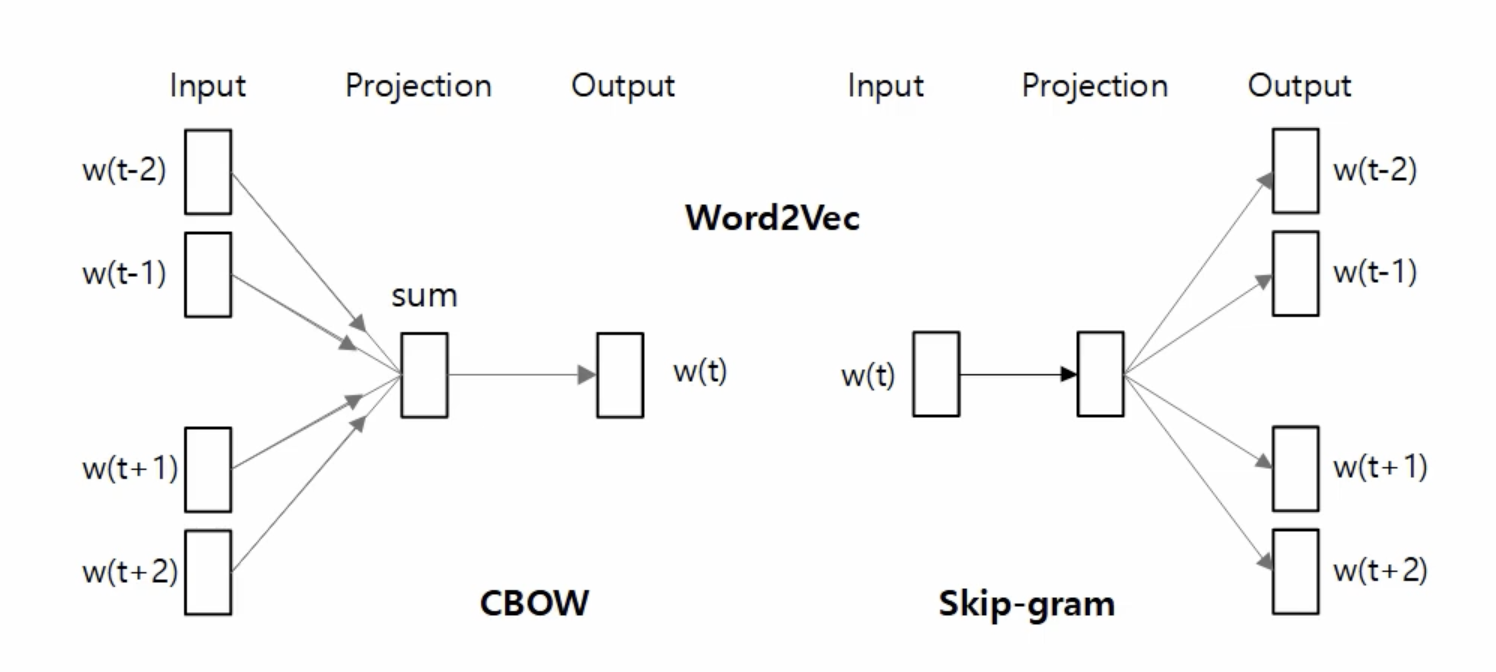

### Why Word2Vec?

- Word embeddings aim to learn compact word vectors from large datasets.
- Traditional **one-hot encoding** is sparse and high-dimensional, treating all words as equally distant and unrelated.
- Word2Vec overcomes this by learning **dense, low-dimensional vectors** encoding meaning through **contextual prediction**.
- Embeddings support semantic tasks (similarity, analogy), improve downstream NLP tasks, and are trained efficiently on massive corpora.

### What are the limitations of Neural Probabilistic Language Models (NPLM)?

- NPLM (Bengio 2003) introduced **neural network–based language models**.
- Used embeddings, hidden layers, and softmax output.
- Complex due to hidden layers and expensive softmax.
- Word2Vec builds on this by:
  - Introducing simpler architectures (no hidden layer).
  - Novel training tricks to speed training (e.g., hierarchical softmax, negative sampling).

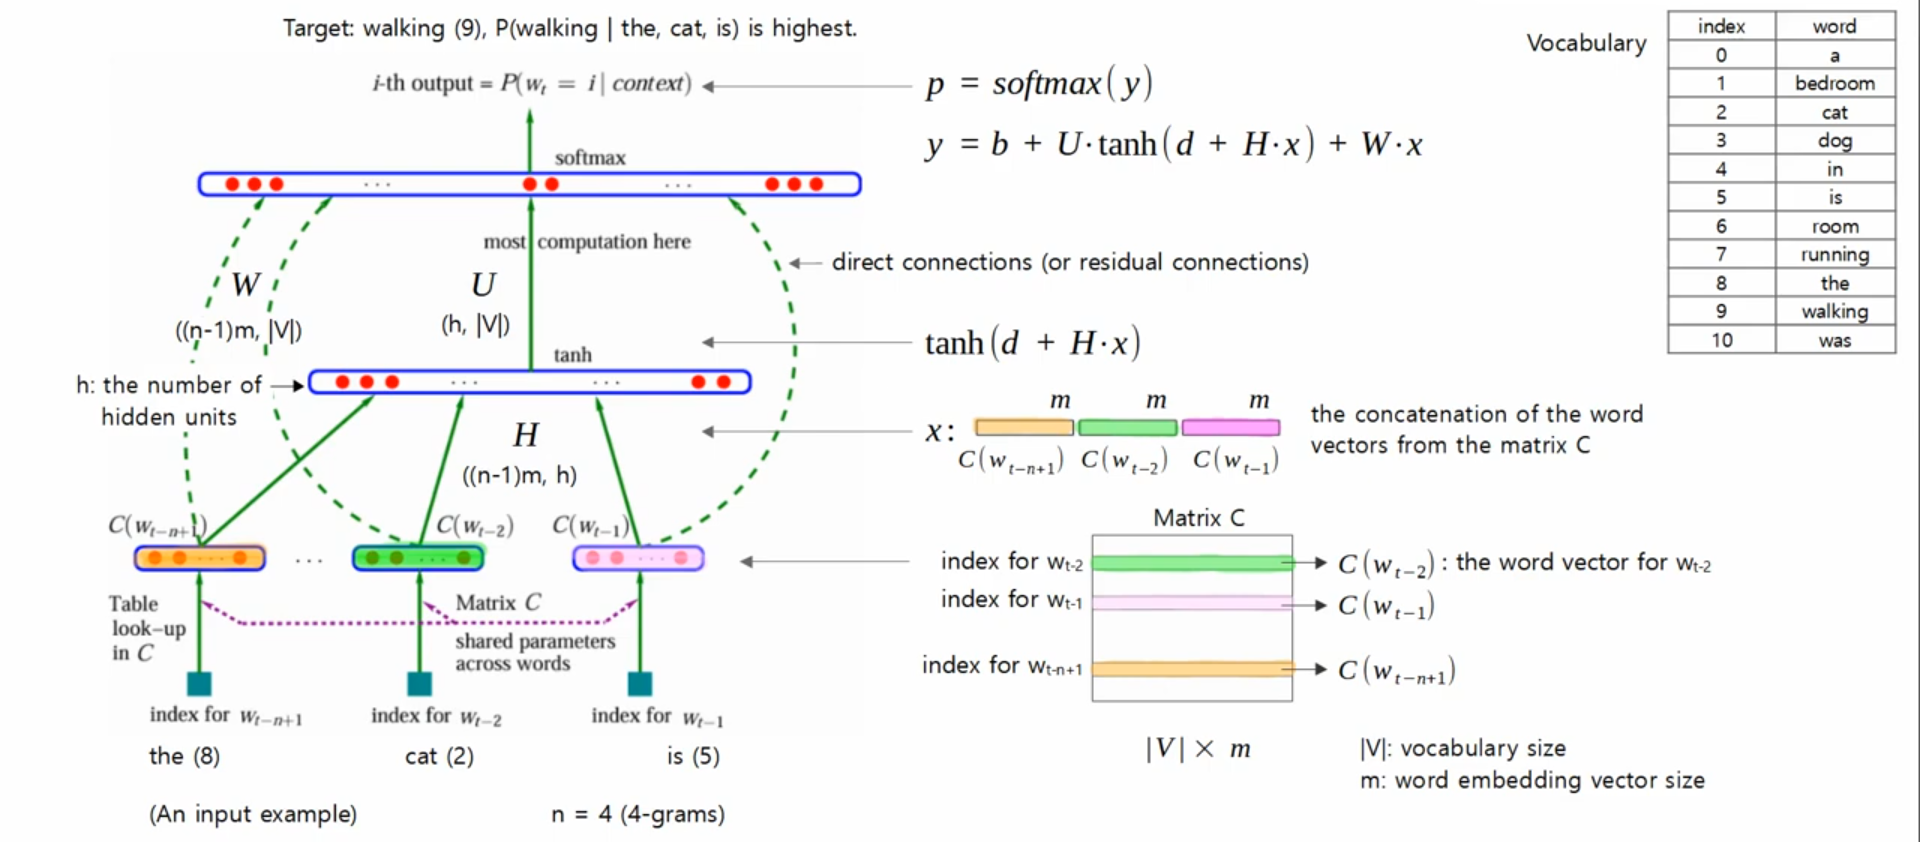

### Continuous Bag-of-Words Model (CBOW)

#### Model Description:

- Predict **center word** from surrounding **context words**.
- Input: Vector representations of surrounding words.
- Output: Probability distribution predicting the central word.
- Network architecture:
  - Embedding layer: Look-up vectors for context words.
  - Averaging or sum of context vectors (order ignored).
  - Softmax layer: Outputs probability distribution over vocabulary.

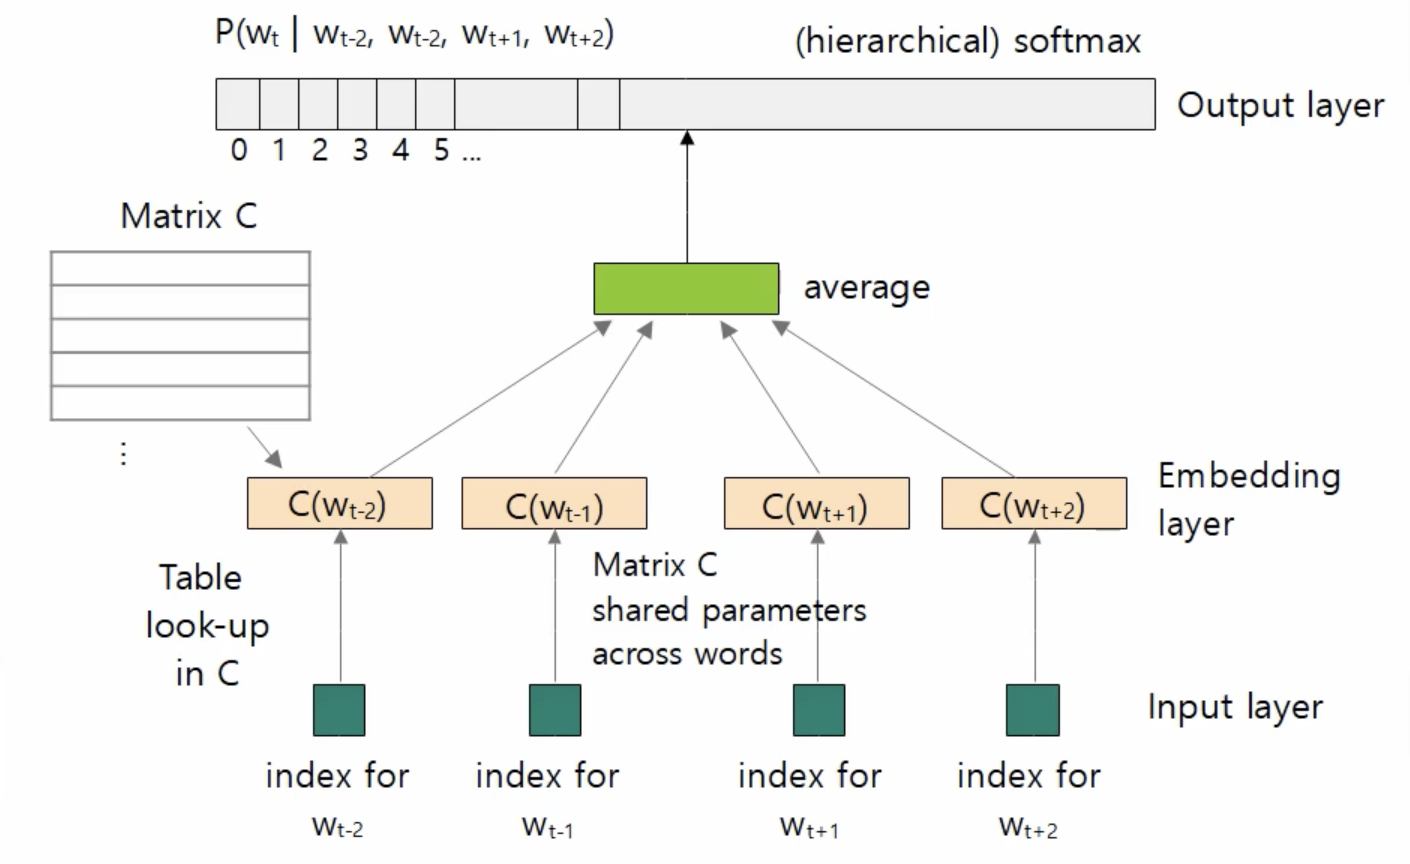

- For a sentence: `"The cat sat on the mat"`, with window size 2:
- Context-target pairs:

| Context Words       | Target Word |
|---------------------|-------------|
| The, sat            | cat         |
| cat, on             | sat         |
| sat, the            | on          |
| on, mat             | the         |

In [ ]:
import numpy as np
import tensorflow as tf
import keras
from keras.layers import Input, Dense, Embedding, Lambda
from keras.models import Model
from tensorflow.keras.preprocessing.text import Tokenizer
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

from collections import Counter
from sklearn.decomposition import PCA

import nltk
from nltk import sent_tokenize, word_tokenize
nltk.download('punkt_tab')
from nltk.corpus import gutenberg, stopwords
nltk.download('gutenberg')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package gutenberg to /root/nltk_data...
[nltk_data]   Unzipping corpora/gutenberg.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

### Dataset Preparation



- Use the **Gutenberg corpus** available from NLTK, containing public domain literary texts.  
- Filter out **stop words** like “the”, “a”, “and”, etc., to focus on meaningful content.  
- Tokenize documents into sentences and words, then remove short sentences (<5 words) and stop words.  
- Result:
  - Around 35K unique words  
  - Nearly 65K sentences  
  - Approximately 1 million total word counts

In [ ]:
# Extend stopwords to " `` ", " ' ' ". "'s", "n't"
stop_words = stopwords.words('english')
print('# Stopwords', len(stop_words))
print(stop_words)

# Stopwords 198
['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan'

In [ ]:
stop_words.extend(("``", "' '", "'s", "n't", "--"))
print('# Stopwords', len(stop_words))

# Stopwords 203


In [ ]:
# Load Gutenberg corpus from NLTK
fileids = gutenberg.fileids()
fileids

['austen-emma.txt',
 'austen-persuasion.txt',
 'austen-sense.txt',
 'bible-kjv.txt',
 'blake-poems.txt',
 'bryant-stories.txt',
 'burgess-busterbrown.txt',
 'carroll-alice.txt',
 'chesterton-ball.txt',
 'chesterton-brown.txt',
 'chesterton-thursday.txt',
 'edgeworth-parents.txt',
 'melville-moby_dick.txt',
 'milton-paradise.txt',
 'shakespeare-caesar.txt',
 'shakespeare-hamlet.txt',
 'shakespeare-macbeth.txt',
 'whitman-leaves.txt']

In [ ]:
gutenberg.raw('shakespeare-hamlet.txt')

"[The Tragedie of Hamlet by William Shakespeare 1599]\n\n\nActus Primus. Scoena Prima.\n\nEnter Barnardo and Francisco two Centinels.\n\n  Barnardo. Who's there?\n  Fran. Nay answer me: Stand & vnfold\nyour selfe\n\n   Bar. Long liue the King\n\n   Fran. Barnardo?\n  Bar. He\n\n   Fran. You come most carefully vpon your houre\n\n   Bar. 'Tis now strook twelue, get thee to bed Francisco\n\n   Fran. For this releefe much thankes: 'Tis bitter cold,\nAnd I am sicke at heart\n\n   Barn. Haue you had quiet Guard?\n  Fran. Not a Mouse stirring\n\n   Barn. Well, goodnight. If you do meet Horatio and\nMarcellus, the Riuals of my Watch, bid them make hast.\nEnter Horatio and Marcellus.\n\n  Fran. I thinke I heare them. Stand: who's there?\n  Hor. Friends to this ground\n\n   Mar. And Leige-men to the Dane\n\n   Fran. Giue you good night\n\n   Mar. O farwel honest Soldier, who hath relieu'd you?\n  Fra. Barnardo ha's my place: giue you goodnight.\n\nExit Fran.\n\n  Mar. Holla Barnardo\n\n   Bar. 

In [ ]:
word_freq = Counter()
sentences_clean = []

# Preprocess: tokenize, lowercase, remove stopwords & short tokens
for fid in fileids:
    raw = nltk.corpus.gutenberg.raw(fid).lower()
    sents = nltk.tokenize.sent_tokenize(raw)
    for s in sents:
        words = nltk.tokenize.word_tokenize(s)
        words = [w for w in words if w.isalpha() and w not in stop_words and len(w) > 1]
        if len(words) >= 5:
            sentences_clean.append(words)
            word_freq.update(words)

print("Unique words:", len(word_freq))
print("Total sentences:", len(sentences_clean))

Unique words: 39732
Total sentences: 68743


### Why Subsampling?



- Frequent words like **"the"**, **"a"**, **"and"** occur extremely often in large corpora (hundreds of millions of times).  
- These words are **less informative** about semantics despite their frequency.  
- Subsampling reduces imbalance by **discarding frequent words probabilistically**, helping models learn better embeddings especially for **rare words**.  

**Subsampling Calculation (Mikolov et al., 2013)**

$$
P(w_i) = 1 - \sqrt{\frac{t}{f(w_i)}}
$$

- $ f(w_i) $ = frequency of word $ w_i $ relative to corpus size.  
- $ t $ = threshold, usually $10^{-5}$.  
- Words with frequency $ f > t $ have higher probability to be discarded; low-frequency words are retained more often.  

**Example:**  
- Word frequency = 0.002 (2000 times in a million words).  
- Threshold $ t = 10^{-3} $.  
- Probability to keep $ = 1 - \sqrt{10^{-3} / 0.002} \approx 0.71 $ → Keep 71% of occurrences.

In [ ]:
# Sub-sampling frequent words
sum_freq = sum(word_freq.values())

def sampling_rate(w, t=1e-3):
    f = word_freq[w] / sum_freq
    return (np.sqrt(f / t) + 1) * (t / f)

sentences_subsampled = []
for sent in sentences_clean:
    subs = [w for w in sent if np.random.rand() < sampling_rate(w)]
    if len(subs) >= 5:
        sentences_subsampled.append(subs)

print("Sentences after subsampling:", len(sentences_subsampled))

Sentences after subsampling: 67302


In [ ]:
# Tokenize & build vocabulary
tokenizer = Tokenizer(oov_token="<OOV>")  # handle out-of-vocab gracefully
tokenizer.fit_on_texts(sentences_subsampled)
word2idx = tokenizer.word_index
idx2word = {v: k for k, v in word2idx.items()}

sequences = tokenizer.texts_to_sequences(sentences_subsampled)
vocab_size = len(word2idx) + 1  # +1 for padding / OOV

print("Vocabulary size:", vocab_size)

Vocabulary size: 39689


In [ ]:
# Build CBOW training data: context → target
window_size = 2  # number of words before and after target
context_size = window_size * 2

contexts = []
targets = []

for seq in sequences:
    for i in range(window_size, len(seq) - window_size):
        context = seq[i-window_size:i] + seq[i+1:i+window_size+1]
        target = seq[i]
        contexts.append(context)
        targets.append(target)

contexts = np.array(contexts)
targets = np.array(targets)

print("Context / target examples:", contexts.shape, targets.shape)

Context / target examples: (622502, 4) (622502,)


### CBOW Model Construction



- Use a **context window size** (e.g., 5-grams) to generate training examples:  
  - Input: Context words (n-1 words)  
  - Output: Target word (center word)

- Example: For the sentence  
  *"the cat is walking in the bedroom"*  
  The model predicts the word “walking” based on the surrounding words.

**Model Architecture**

- **Input Layer:** Sequence of context word indices  
- **Embedding Layer:** Lookup embedding vectors from matrix $ C \in \mathbb{R}^{V \times m} $  
- **Projection:** Average or sum the embeddings of context words (latent vector of size $ m $)  
- **Output Layer:** Softmax over vocabulary predicting target word probability (standard softmax for simplicity; hierarchical softmax used in original paper)

In [ ]:
# Define a simple CBOW model in Keras
embedding_dim = 100

# Input: contexts (context_size words)
input_ctx = Input(shape=(context_size,), dtype='int32')
emb = Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=context_size)
ctx_emb = emb(input_ctx)
# CBOW: average embeddings
avg_emb = Lambda(lambda x: tf.reduce_mean(x, axis=1))(ctx_emb)
output = Dense(vocab_size, activation='softmax')(avg_emb)

model = Model(input_ctx, output)
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam')

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 4, 100)         │     3,968,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 39689)          │     4,008,589 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,977,489 (30.43 MB)

 Trainable params: 7,977,489 (30.43 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train model
hist = model.fit(contexts, targets, epochs=10, shuffle = True, batch_size=2048)

Epoch 1/10
304/304 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - loss: 7.2671
Epoch 2/10
304/304 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - loss: 7.1563
Epoch 3/10
304/304 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - loss: 7.0462
Epoch 4/10
304/304 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - loss: 6.9285
Epoch 5/10
304/304 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - loss: 6.8264
Epoch 6/10
304/304 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - loss: 6.7194
Epoch 7/10
304/304 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - loss: 6.6171
Epoch 8/10
304/304 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - loss: 6.5085
Epoch 9/10
304/304 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - loss: 6.4079
Epoch 10/10
304/304 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - loss: 6.3121


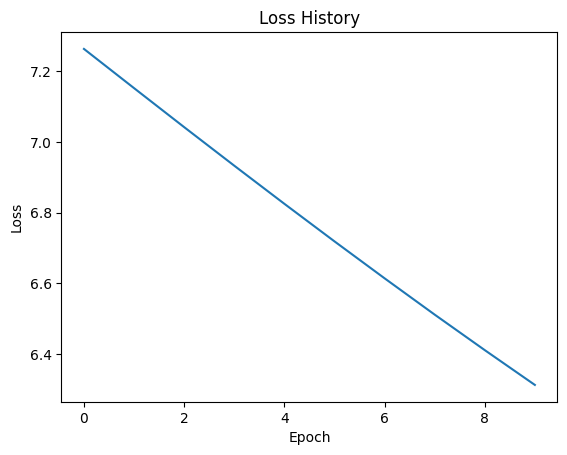

In [ ]:
# Plot Training Loss History
plt.plot(hist.history['loss'])
plt.title("Loss History")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [ ]:
# Extract embeddings
emb_matrix = model.get_layer('embedding').get_weights()[0]  # shape: (vocab_size, embedding_dim)
emb_matrix

array([[ 3.5485450e-02,  6.5625086e-03, -2.0187629e-02, ...,
         3.8478184e-02, -2.7082115e-04, -1.4657140e-02],
       [ 5.2496307e-03,  5.5839792e-03, -1.1920445e-03, ...,
        -2.0795155e-02, -1.6544510e-02, -2.5235558e-02],
       [-7.9280120e-01, -7.4168712e-01,  1.1868858e+00, ...,
        -9.5668828e-01, -1.6110895e+00,  2.4210341e-02],
       ...,
       [-2.8312635e-01,  2.8358343e-01, -7.1176335e-02, ...,
        -1.6273700e-01,  3.0698484e-01,  3.4124646e-02],
       [-7.6632664e-02,  5.4298288e-01,  2.2778744e-01, ...,
         6.9282308e-02, -2.0802802e-01,  2.1549098e-01],
       [ 4.6988934e-01,  4.3457234e-01,  1.3023724e-01, ...,
        -4.1049427e-01,  2.1243669e-01,  3.6037701e-01]], dtype=float32)

In [ ]:
# Inspect Word Embedding: Example for the word "mother"
print("Embedding vector for 'mother':")
print(emb_matrix[word2idx['mother']].round(3))

Embedding vector for 'mother':
[-0.069 -0.294 -0.121  0.37   0.685  0.484 -0.935  0.787 -0.575  0.098
  0.048 -0.276  0.186  0.371 -0.729  0.76  -0.894 -0.338  0.498  0.888
  1.043  0.929  0.661  0.459  0.999  0.556 -1.344  0.462  0.725  0.48
 -0.382  0.637 -0.294 -0.789  0.553  1.334 -0.187 -0.092 -1.551 -0.366
 -0.649 -0.767 -0.88  -0.313 -0.49   0.744  0.58   0.912 -0.311 -0.663
  1.02  -0.389 -1.265 -0.163  0.901  0.513  1.267  0.205 -0.548 -0.867
 -0.587  0.266  0.593  1.031  1.571  0.93  -0.048 -1.043 -0.306  1.01
  0.689  0.555 -0.65  -1.069 -0.219  0.165 -0.642 -0.705  0.624  0.62
 -1.23  -0.144 -0.352 -0.933  0.773 -0.257 -0.793 -0.653  0.317  0.143
  1.447 -0.164  0.874  0.67   0.269 -0.106 -0.075  0.205 -0.803  1.034]


### Embedding Visualization



- After training, extract $ embedding $ matrix rows as word embeddings.  
- Apply **PCA** to reduce from embedding dimension (e.g., 32) to 2D for visual inspection.  
- Words with similar meanings cluster together visually:  
  - Flower names grouped  
  - Country names grouped  
  - Family-related words grouped  

In [ ]:
# Get embedding for a word
def get_vec(word):
    idx = word2idx.get(word, word2idx.get("<OOV>"))
    return emb_matrix[idx]

print("Vector for 'king':", get_vec('king'))

Vector for 'king': [ 0.2699607  -0.11686586 -0.7298152   0.9343589  -0.29139408  0.78227466
 -0.8529284   0.39662573  0.38850585 -0.53939897 -0.58843976 -1.0511633
 -0.5033407  -0.6135479   0.11924172 -0.00568401 -0.54565036 -0.88307184
  0.23660181 -0.26917604  1.0677544  -0.26747882  0.648034    0.99913484
 -0.77425206 -0.34489954  0.3290409  -0.9980302  -0.22967032  0.7575047
  0.38609082  1.8842056   1.980954   -1.6004254  -1.0622938   1.03075
  0.69487524 -0.8690364  -1.2658271   0.2856958  -0.6815656  -2.4643953
  1.9860032   0.8087131   1.479522   -0.22587764  0.33175534  0.93801737
 -1.811479   -0.6239565   0.8634254   1.3865047  -0.62063384 -0.32501462
  0.61371493 -1.1217272   0.5930518  -0.45389324  1.4546463  -0.11312806
 -0.60633975  1.6067462  -0.693656    0.5155927  -1.383026    0.02274707
  0.35424197 -0.968774    0.842561   -0.30087462  0.9664469  -0.31911966
 -1.7327113   1.9247591   0.43666568  0.32823884  1.2505122  -1.0552818
 -1.1606416  -1.1213925  -0.7727924  -1

In [ ]:
# Dimensionality Reduction of Embedding Matrix (32 → 2 dims)
pca = PCA(n_components=2)
pca_C = pca.fit_transform(emb_matrix)

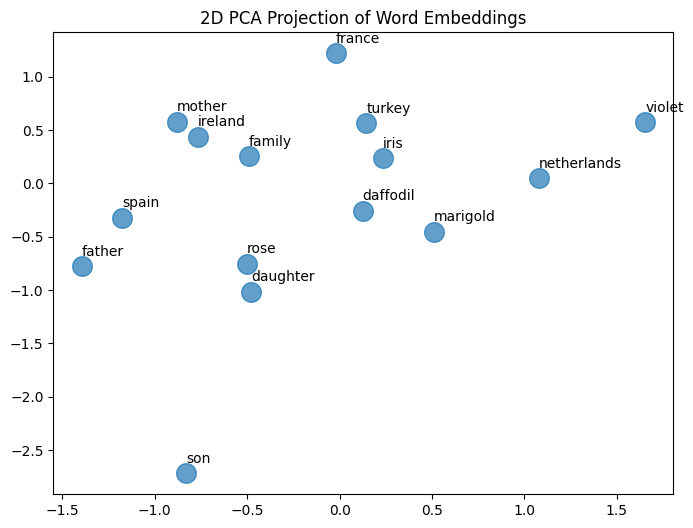

In [ ]:
# Visualize Selected Words in 2D Embedding Space
words = [
    'daffodil', 'marigold', 'iris', 'rose', 'violet',
    'france', 'netherlands', 'spain', 'turkey', 'ireland',
    'mother', 'father', 'son', 'daughter', 'family'
]

# filter out words that may not exist in vocabulary
words = [w for w in words if w in word2idx]

words_idx = np.array([word2idx[w] for w in words])
words_vec = pca_C[words_idx]

# Coordinates
x = words_vec[:, 0]
y = words_vec[:, 1]

plt.figure(figsize=(8, 6))
plt.scatter(x, y, s=200, alpha=0.7)

for i, word in enumerate(words):
    plt.annotate(word, (x[i], y[i] + 0.1))

plt.title("2D PCA Projection of Word Embeddings")
plt.show()

- Subsampling reduces the influence of irrelevant frequent words, improving **rare word representation**.  
- CBOW predicts the center word using surrounding context embeddings, enabling **distributed representation learning**.  
- Neural network model with embedding lookup + average + softmax is simple yet effective.  
- Visualization demonstrates semantic structure captured by the learned embeddings.  

## Skip-Gram Model

### Model Description:

- Inverse of CBOW.
````
CBOW: Context → Target Word
Skip-Gram: Target Word → Multiple Context Words
````
- Predict **surrounding context words** from the **center word**.
- Input: Vector for center word.
- Output: Multiple softmax layers – one for each context word – predicting likely neighbors.
- Learns better representations for rare words.

**Embedding Matrix**

- Both CBOW and Skip-Gram learn an embedding matrix $C$ of size $V \times M$, where:
  - $V$ = vocabulary size
  - $M$ = embedding dimension (e.g., 100–300)
- Each row is a dense vector representing a word in continuous space.


**Semantic Relationships in Embeddings**

- Learned vectors encode semantic and syntactic relationships.
- Vector arithmetic works, for example:
  $$
  \text{king} - \text{man} + \text{woman} \approx \text{queen}
  $$
- Similar words cluster together in the vector space.

### Two Implementation Approaches

1. **Multiple Output Layers** (one per context position)
2. **Single Output Layer** (repeat center word for each context)

### Multiple Output Layers

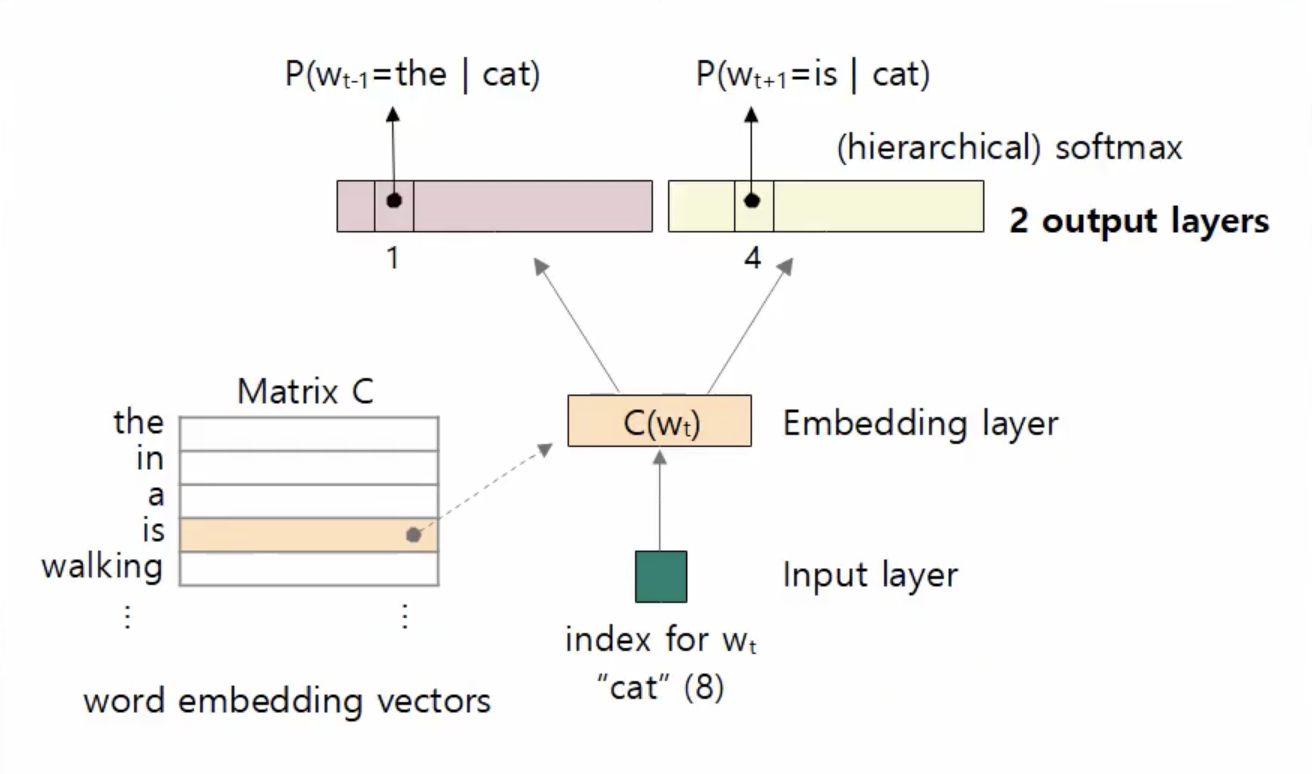

#### Training Data Generation



**Corpus Example** (5 sentences):
```
["the", "cat", "sat", "on", "the", "mat"]
```

**Tri-gram Sliding Window** (window=1, total context=2):
```
Center: cat    → Context: [the, sat]
Center: sat    → Context: [cat, on]
Center: on     → Context: [sat, the]

In [ ]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, Reshape, Dense
from tensorflow.keras.models import Model

In [ ]:
# Settings / hyperparams
EMBEDDING_DIM = 64       # embedding size (small for demo; increase for better quality)
WINDOW = 1               # context window on each side (1 -> left and right)
CONTEXT_SIZE = WINDOW * 2
BATCH_SIZE = 4096
EPOCHS = 20              # small for demo; increase when using a large corpus
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [ ]:
# compute vocabulary sizes
vocab_size = len(word2idx) + 1  # +1 because tokenizer used 1..N (0 reserved)
print("Vocab size (with reserved 0):", vocab_size)
print("Number of sequences (sentences):", len(sequences))

Vocab size (with reserved 0): 39689
Number of sequences (sentences): 67302


In [ ]:
# Build Skip-gram training examples (center -> left,right)
centers = []
lefts = []
rights = []

for seq in sequences:
    if len(seq) < 2 * WINDOW + 1:
        continue  # skip sentences too short for full window
    for i in range(WINDOW, len(seq) - WINDOW):
        center = seq[i]
        # left and right context words (for WINDOW=1)
        left = seq[i - WINDOW]
        right = seq[i + WINDOW]
        centers.append([center])  # model expects shape (batch, 1)
        lefts.append(left)
        rights.append(right)

centers = np.array(centers, dtype=np.int32)   # shape (N,1)
lefts = np.array(lefts, dtype=np.int32)       # shape (N,)
rights = np.array(rights, dtype=np.int32)     # shape (N,)

print("Training examples:", centers.shape[0])

Training examples: 757106


In [ ]:
# Build the Keras model (Skip-gram with two output heads)
# Input: center word index (shape=(None,1))
input_center = Input(batch_shape=(None, 1), dtype='int32', name='center_input')
# Shared embedding layer: maps word index -> vector (vocab_size x EMBEDDING_DIM)
emb_layer = Embedding(input_dim=vocab_size,
                      output_dim=EMBEDDING_DIM,
                      input_length=1,
                      name='word_embedding')

# Lookup embedding for center
emb = emb_layer(input_center)          # shape -> (None, 1, EMBEDDING_DIM)
emb = Reshape((EMBEDDING_DIM,))(emb)   # shape -> (None, EMBEDDING_DIM)

# Two separate softmax output heads (predict left and right context)
left_output = Dense(vocab_size, activation='softmax', name='left_output')(emb)
right_output = Dense(vocab_size, activation='softmax', name='right_output')(emb)

model = Model(inputs=input_center, outputs=[left_output, right_output])
model.compile(
    optimizer='adam',
    loss=['sparse_categorical_crossentropy', 'sparse_categorical_crossentropy']
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ center_input        │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_embedding      │ (None, 1, 64)     │  2,540,096 │ center_input[0][… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 64)        │          0 │ word_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ left_output (Dense) │ (None, 39689)     │  2,579,785 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ right_output        │ (None, 39689)     │  2,579,785 │ reshape[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 7,699,666 (29.37 MB)

 Trainable params: 7,699,666 (29.37 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model
hist = model.fit(
    x=centers,
    y=[lefts, rights],
    batch_size=min(BATCH_SIZE, centers.shape[0]),
    epochs=EPOCHS,
    validation_split=0.05,
    verbose=2
)

Epoch 1/20
176/176 - 24s - 136ms/step - left_output_loss: 9.9841 - loss: 19.9901 - right_output_loss: 10.0010 - val_left_output_loss: 9.7918 - val_loss: 19.5843 - val_right_output_loss: 9.7842
Epoch 2/20
176/176 - 34s - 191ms/step - left_output_loss: 8.6017 - loss: 17.2659 - right_output_loss: 8.6631 - val_left_output_loss: 9.5864 - val_loss: 19.1674 - val_right_output_loss: 9.5709
Epoch 3/20
176/176 - 15s - 87ms/step - left_output_loss: 8.3208 - loss: 16.7085 - right_output_loss: 8.3871 - val_left_output_loss: 9.5359 - val_loss: 19.0592 - val_right_output_loss: 9.5133
Epoch 4/20
176/176 - 15s - 85ms/step - left_output_loss: 8.1729 - loss: 16.4144 - right_output_loss: 8.2410 - val_left_output_loss: 9.5138 - val_loss: 19.0094 - val_right_output_loss: 9.4861
Epoch 5/20
176/176 - 15s - 87ms/step - left_output_loss: 8.0568 - loss: 16.1851 - right_output_loss: 8.1279 - val_left_output_loss: 9.5031 - val_loss: 18.9839 - val_right_output_loss: 9.4718
Epoch 6/20
176/176 - 16s - 89ms/step - lef

In [ ]:
# Plot loss history
plt.plot(hist.history['loss'], label='total_loss')
if 'val_loss' in hist.history:
    plt.plot(hist.history['val_loss'], label='val_loss')
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Training Loss")
plt.legend()
plt.show()

In [ ]:
# Extract embedding matrix and inspect vectors
emb_matrix = model.get_layer('word_embedding').get_weights()[0]  # shape (vocab_size, EMBEDDING_DIM)

def get_vector(word):
    """Get embedding vector for a given word (returns None if not in vocab)"""
    idx = word2idx.get(word)
    if idx is None:
        print(f"Word '{word}' not in vocabulary.")
        return None
    return emb_matrix[idx]

# Example: inspect 'mother' if present
if 'mother' in word2idx:
    print("Embedding for 'mother':", np.round(get_vector('mother'), 4))
else:
    print("'mother' not in vocab (toy corpus).")

Embedding for 'mother': [ 0.5873  0.8069 -0.9879 -0.089   0.3509 -0.1595  1.0515 -0.4469 -1.0789
 -0.2718 -0.1359 -0.2524  0.9119 -0.1488 -0.0097 -0.1223  0.3891 -0.0222
  0.3927 -0.2307  0.1594  0.5051 -0.8294  0.1758 -0.1203 -0.1116  0.7383
 -0.6127  0.7699 -0.7325 -0.0504  0.0799 -1.0352 -0.4459  0.785  -0.7556
 -0.7413  0.1413 -0.3838  0.8627  0.1269  0.1565  1.2569 -0.6043 -0.0859
 -0.4597  0.0474  1.0578 -0.8968  1.0405  0.2305 -0.1209 -1.1248  0.1481
  0.8397 -0.3869 -0.5391 -0.6193 -0.2307  0.3452  0.6829  0.6931 -0.4294
  0.8532]


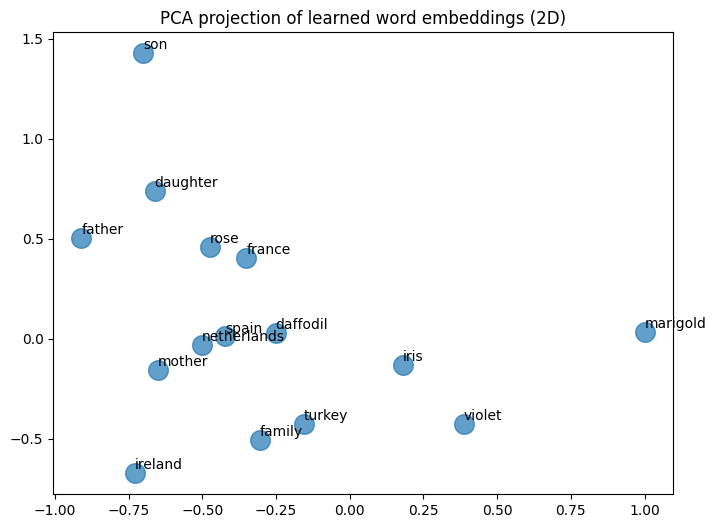

In [ ]:
# PCA visualization for selected words
# choose some words to visualize (filter to those present in vocab)
candidate_words = [
    'daffodil', 'marigold', 'iris', 'rose', 'violet',
    'france', 'netherlands', 'spain', 'turkey', 'ireland',
    'mother', 'father', 'son', 'daughter', 'family'
]
words = [w for w in candidate_words if w in word2idx]
if len(words) >= 2:
    idxs = np.array([word2idx[w] for w in words])
    pca = PCA(n_components=2, random_state=SEED)
    C2 = pca.fit_transform(emb_matrix)   # project all embeddings to 2D
    words_vec = C2[idxs]
    x = words_vec[:, 0]
    y = words_vec[:, 1]
    plt.figure(figsize=(8, 6))
    plt.scatter(x, y, s=200, alpha=0.7)
    for i, w in enumerate(words):
        plt.annotate(w, (x[i], y[i] + 0.02))
    plt.title("PCA projection of learned word embeddings (2D)")
    plt.show()
else:
    print("Not enough candidate words present in vocabulary for PCA demo:", words)

In [ ]:
# Utility: find nearest neighbors (cosine similarity)
def nearest_neighbors(word, top_k=5):
    if word not in word2idx:
        print(f"{word} not in vocabulary.")
        return []
    idx = word2idx[word]
    vec = emb_matrix[idx:idx+1]  # shape (1,D)
    # normalize embeddings for cosine similarity
    emb_norm = normalize(emb_matrix)
    scores = emb_norm.dot(emb_norm[idx])  # cosine similarities
    # argsort descending
    nearest = np.argsort(-scores)[1: top_k + 1]  # skip self at index 0
    return [(idx2word.get(int(i), '<UNK>'), float(scores[int(i)])) for i in nearest]

sample_word = next(iter(word2idx.keys()))  # just pick any word from vocab
print("Sample word (vocab):", sample_word)
print("Nearest neighbors:", nearest_neighbors(sample_word, top_k=5))

Sample word (vocab): <OOV>
Nearest neighbors: [('spurrings', 0.4647446274757385), ('ecuador', 0.45674842596054077), ('gleeful', 0.4250204861164093), ('direst', 0.4164152145385742), ('greco', 0.4160856604576111)]


### Single Output Layer

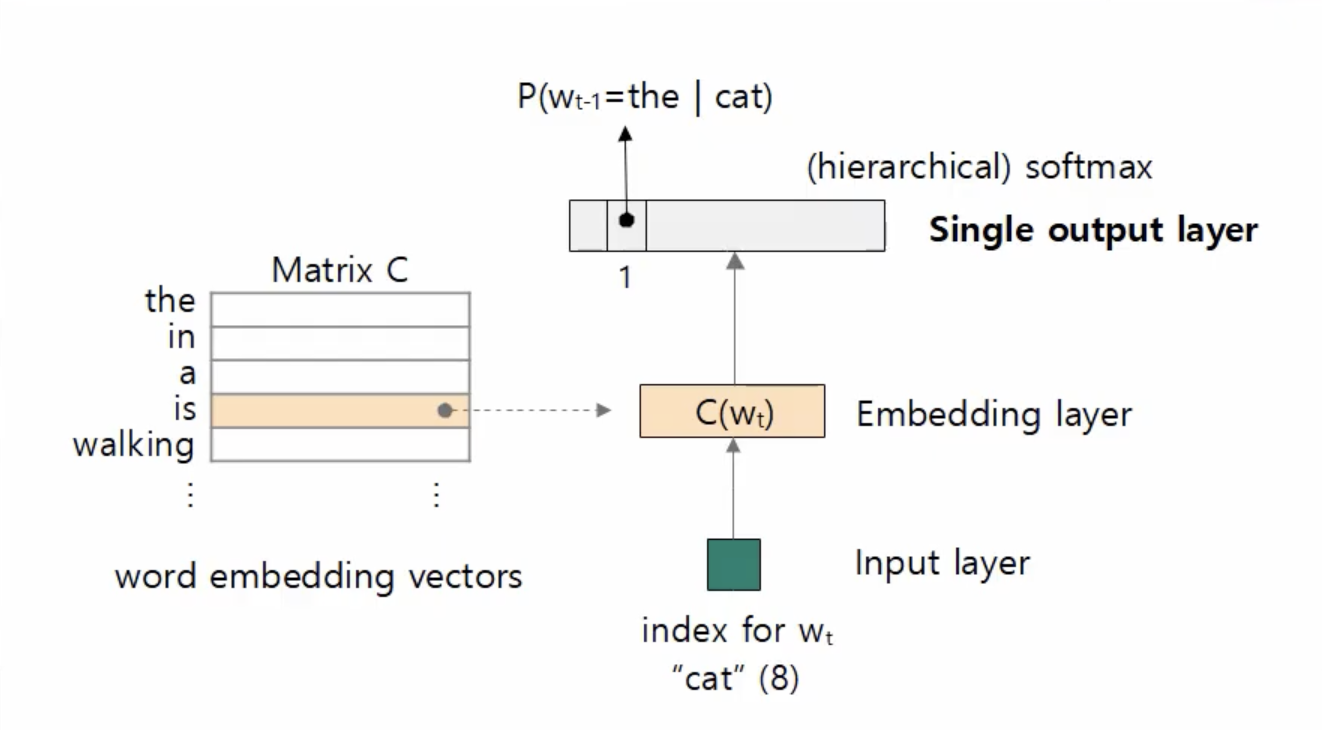

In [ ]:
import numpy as np
import nltk
from tensorflow.keras.layers import Input, Embedding, Dense, Reshape
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt

In [ ]:
# Create training dataset using skip-gram (context → target)
n_grams = 3
x_train = []
y_train = []

for sequence in sequences:
    if len(sequence) >= n_grams:
        for a, b, c in nltk.ngrams(sequence, n_grams):
            x_train.append(b)   # center word
            y_train.append(a)   # left context
            x_train.append(b)
            y_train.append(c)   # right context

x_train = np.array(x_train).reshape(-1, 1)
y_train = np.array(y_train).reshape(-1, 1)

In [ ]:
# Model hyperparameters
n_vocab = len(word2idx)
n_emb = 16   # embedding dimension

In [ ]:
# Skip-Gram Model (single output)
x_input = Input(batch_shape=(None, 1))
x_emb = Embedding(n_vocab, n_emb, name='emb')(x_input)  # (None,1,16)
x_emb = Reshape((n_emb,))(x_emb)                        # (None,16)

y_output = Dense(n_vocab, activation='softmax')(x_emb)  # prediction

model = Model(x_input, y_output)
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam')
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ emb (Embedding)                 │ (None, 1, 16)          │       635,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 39688)          │       674,696 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,309,704 (5.00 MB)

 Trainable params: 1,309,704 (5.00 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train model
hist = model.fit(x_train, y_train, batch_size=4096, epochs=20)

Epoch 1/20
370/370 ━━━━━━━━━━━━━━━━━━━━ 16s 34ms/step - loss: nan
Epoch 2/20
370/370 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - loss: nan
Epoch 3/20
370/370 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - loss: nan
Epoch 4/20
370/370 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - loss: nan
Epoch 5/20
370/370 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - loss: nan
Epoch 6/20
370/370 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - loss: nan
Epoch 7/20
370/370 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - loss: nan
Epoch 8/20
370/370 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - loss: nan
Epoch 9/20
370/370 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - loss: nan
Epoch 10/20
370/370 ━━━━━━━━━━━━━━━━━━━━ 21s 31ms/step - loss: nan
Epoch 11/20
370/370 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - loss: nan
Epoch 12/20
370/370 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - loss: nan
Epoch 13/20
370/370 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - loss: nan
Epoch 14/20
370/370 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - loss: nan
Epoch 15/20
370/370 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - loss: nan
Epoc

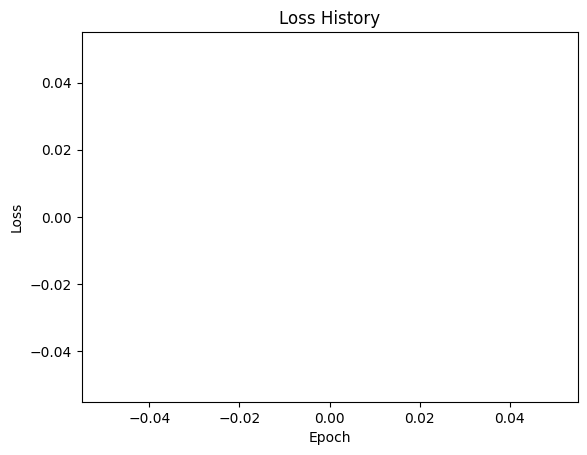

In [ ]:
# Plot loss
plt.plot(hist.history['loss'])
plt.title("Loss History")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [ ]:
# Extract Learned Embeddings
C = model.get_layer('emb').get_weights()[0]

print("Embedding for 'mother':")
print(C[word2idx['mother']].round(3))

Embedding for 'mother':
[nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]


In [ ]:
# PCA for visualization
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_C = pca.fit_transform(C)

# Words to visualize
words = [
    'daffodil', 'marigold', 'iris', 'rose', 'violet',
    'france', 'netherlands', 'spain', 'turkey', 'ireland',
    'mother', 'father', 'son', 'daughter', 'family'
]

words_idx = np.array([word2idx[w] for w in words])
words_vec = pca_C[words_idx]

# Plot embeddings in 2D
x = words_vec[:, 0]
y = words_vec[:, 1]

plt.figure(figsize=(8, 6))
plt.scatter(x, y, s=200, alpha=0.7, c='red')

for i in range(len(words)):
    plt.annotate(words[i], (x[i], y[i] + 0.1))

plt.title("2D Visualization of Word Embeddings")
plt.show()

ValueError: Input X contains NaN.
PCA does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

## Word Analogies

Word analogies exemplify the **semantic relationships captured by neural word embeddings like Word2Vec and GloVe**.

The classic form is
$$
king - man ≈ queen - woman
$$

where vector arithmetic isolates relational concepts such as gender or royalty.

- These emerge naturally from training on co-occurrence patterns, without explicit analogy optimization, distinguishing embeddings from simpler methods like TF-IDF .
- Geometrically, subtracting vectors yields a difference vector (e.g., Woman - Man ≈ Queen - King), capturing direction and magnitude of semantic shifts.

Analogies span categories like royalty, geography, nationality, family, and grammar:
- King - Queen ≈ Prince - Princess (royalty and gender)
- France - Paris ≈ Germany - Berlin (country - capital)
- Japan - Japanese ≈ China - Chinese (country - nationality)
- Brother - Sister ≈ Uncle - Aunt (male - female family relation)
- Walk - Walking ≈ Swim - Swimming (verb base - gerund)

#### Why Analogies Emerge?



Embeddings form a V × D matrix where rows are word vectors optimized for local co-occurrences (e.g., skip-gram in Word2Vec). Analogies arise as linear substructures in this high-dimensional space, absent in count-based matrices like TF-IDF despite identical shape. This suggests embeddings capture hierarchical semantics through distributed representations, a key insight for NLP research .

#### How to find vector analogoes?

- Given three words (a, b, c), compute test_vector = embedding(a) - embedding(b) + embedding(c) to predict d where a - b ≈ d - c.
- Search the vocabulary for the word whose embedding minimizes distance to test_vector.
- Cosine distance is preferred over Euclidean as it focuses on direction, ignoring magnitude:  
$$ \text{distance} = 1 - \cos(\theta) = 1 - \frac{\mathbf{u} \cdot \mathbf{v}}{||\mathbf{u}|| \ ||\mathbf{v}||} $$ (ranges 0 for identical direction to 2 for opposite).

In [ ]:
# Vectorized NumPy Implementation (fast for large V x D matrices)
# emb_matrix (V x D), word_to_idx dict, idx_to_word list
import numpy as np
def analogy_vectorized(emb_matrix, word_to_idx, idx_to_word, a, b, c):
    idx_a, idx_b, idx_c = word_to_idx[a], word_to_idx[b], word_to_idx[c]
    test_vec = emb_matrix[idx_a] - emb_matrix[idx_b] + emb_matrix[idx_c]

    # Cosine distances: 1 - (emb_matrix @ test_vec) / (norms_emb * norm_test)
    norms_emb = np.linalg.norm(emb_matrix, axis=1, keepdims=True)
    norm_test = np.linalg.norm(test_vec)
    cos_sims = np.dot(emb_matrix, test_vec) / (norms_emb * norm_test)
    distances = 1 - cos_sims

    # Exclude input words, find min distance index
    mask = np.ones(len(idx_to_word), dtype=bool)
    mask[[idx_a, idx_b, idx_c]] = False
    closest_idx = np.argmin(distances[mask])
    best_idx = np.where(mask)[0][closest_idx]
    return idx_to_word[best_idx], distances[best_idx]

#### Dimensionality Challenges in Embeddings

Humans perceive up to 2-3 dimensions effectively, making high-dimensional data like TF-IDF vectors (V × D, where V is vocabulary size and D is document count) invisible without reduction. t-SNE addresses this by projecting high-D data to 2D while preserving local structure, enabling visualization of semantic clusters. Neural embeddings (Word2Vec, GloVe) share this V × D shape but capture richer relationships than count-based TF-IDF .

#### Do TF-IDF Embeddings Make Sense?

TF-IDF produces word-document matrices where nearby words in reduced space should be semantically related (e.g., dog near canine, programmer near software, sushi near sashimi), even if analogies fail. Analysis reveals partial success: clusters form around themes like politics (government, parliament), geography (Canada, Australian), military (troops, army), education (university, degree), and sciences (electron, DNA). However, cross-cluster links (e.g., soldiers under trade) and outliers (numbers, months) show limitations.

Words are ['canine' 'code' 'country' 'dogs' 'grace' 'king' 'leads' 'nation' 'pets'
 'programmers' 'queen' 'rules' 'software' 'write']
TF-IDF matrix shape: (14, 4)


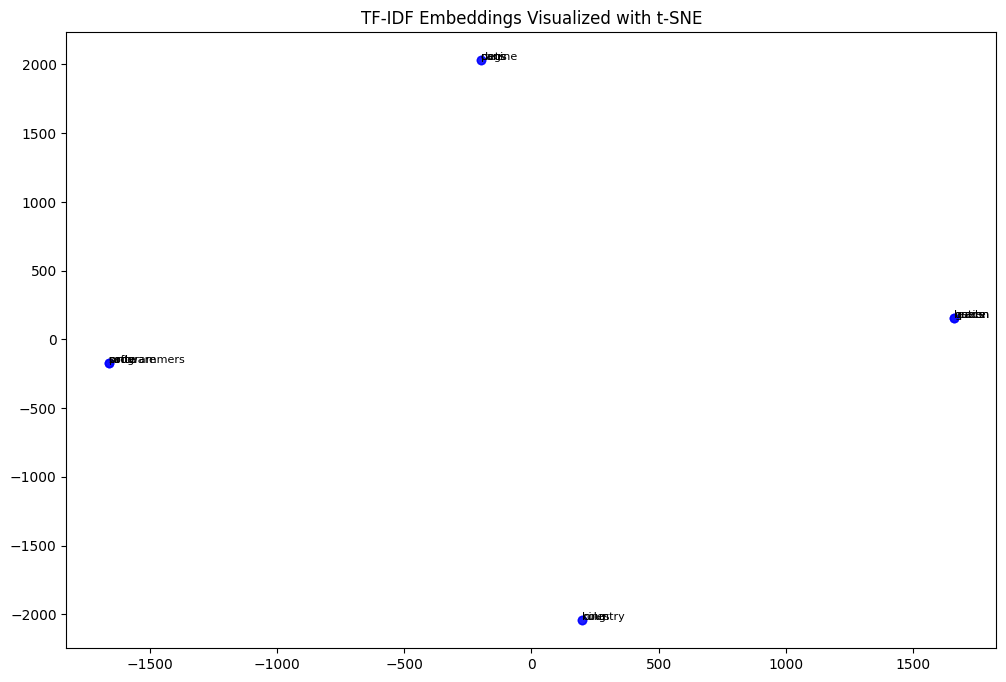

In [ ]:
# TF-IDF + t-SNE Visualization
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from collections import Counter

# Step 1: Load corpus (e.g., Brown or Wikipedia texts)
corpus = [
    "The king rules the country.",
    "The queen leads the nation with grace.",
    "Dogs are canine pets.",
    "Programmers write software code.",
    # ... load full corpus from file
]

# Step 2: TF-IDF vectorization (V x D matrix)
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
tfidf_matrix = vectorizer.fit_transform(corpus)  # Shape: (n_docs, V) -> transpose for V x D
word_vectors = tfidf_matrix.T.toarray()  # V x D
words = vectorizer.get_feature_names_out()

print(f'Words are', words)
print(f"TF-IDF matrix shape: {word_vectors.shape}")  # e.g., (5000, len(corpus))

# Step 3: t-SNE dimensionality reduction to 2D
tsne = TSNE(n_components=2, perplexity=5, random_state = 1)
embed_2d = tsne.fit_transform(word_vectors)

# Step 4: Plot clusters
plt.figure(figsize=(12, 8))
scatter = plt.scatter(embed_2d[:, 0], embed_2d[:, 1], c='blue', alpha=0.5)
for i, word in enumerate(words[:1000]):  # Subset for visibility
    plt.annotate(word, (embed_2d[i, 0], embed_2d[i, 1]), fontsize=8)
plt.title("TF-IDF Embeddings Visualized with t-SNE")
plt.show()

### Pretrained Word2Vec

In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 50.7 MB/s eta 0:00:00


The original Word2Vec GoogleNews vectors are stored in a binary format (~3.4GB). The Gensim library provides a convenient loader so you don’t need to manually parse the binary file.

In [ ]:
from gensim.models import KeyedVectors

Load Pre-trained Google Word2Vec Vectors

In [ ]:
!wget 'https://github.com/mmihaltz/word2vec-GoogleNews-vectors/raw/refs/heads/master/GoogleNews-vectors-negative300.bin.gz'

--2025-12-10 06:57:44--  https://github.com/mmihaltz/word2vec-GoogleNews-vectors/raw/refs/heads/master/GoogleNews-vectors-negative300.bin.gz
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://media.githubusercontent.com/media/mmihaltz/word2vec-GoogleNews-vectors/refs/heads/master/GoogleNews-vectors-negative300.bin.gz [following]
--2025-12-10 06:57:45--  https://media.githubusercontent.com/media/mmihaltz/word2vec-GoogleNews-vectors/refs/heads/master/GoogleNews-vectors-negative300.bin.gz
Resolving media.githubusercontent.com (media.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.108.133, ...
Connecting to media.githubusercontent.com (media.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1647046227 (1.5G) [application/octet-stream]
Saving to: ‘GoogleNews-vectors-negative

In [ ]:
# Path to Google’s pretrained 300-dimensional Word2Vec vectors
MODEL_PATH = "/content/GoogleNews-vectors-negative300.bin.gz"

print("Loading pre-trained Word2Vec vectors…")
word_vectors = KeyedVectors.load_word2vec_format(MODEL_PATH, binary=True)
word_vectors

Loading pre-trained Word2Vec vectors…


Analogy Solver

In [ ]:
def analogy(a, b, c, topn=1):
    """
    Solves word analogies of form: A - B = X - C
    Example: king - man = queen - woman
    """

    result = word_vectors.most_similar(
        positive=[a, c],
        negative=[b],
        topn=topn
    )
    best_word = result[0][0]

    print(f"Analogy: '{a}' - '{b}' ≈ '{best_word}' - '{c}'")
    return result

In [ ]:
analogy('king','man', 'women', topn=10)

Analogy: 'king' - 'man' ≈ 'queen' - 'women'


[('queen', 0.4827326238155365),
 ('queens', 0.466781347990036),
 ('kumaris', 0.4653734564781189),
 ('kings', 0.4558638632297516),
 ('womens', 0.422832190990448),
 ('princes', 0.4176960587501526),
 ('Al_Anqari', 0.41725507378578186),
 ('concubines', 0.4011078476905823),
 ('monarch', 0.3962482810020447),
 ('monarchy', 0.39430150389671326)]

In [ ]:
analogy('king','hero', 'heroine', topn=10)

Analogy: 'king' - 'hero' ≈ 'queen' - 'heroine'


[('queen', 0.6643372774124146),
 ('monarch', 0.5712066888809204),
 ('princess', 0.5646905899047852),
 ('queens', 0.5219783186912537),
 ('prince', 0.48868241906166077),
 ('crown_prince', 0.4806520640850067),
 ('courtesan', 0.4791736900806427),
 ('empress', 0.478889524936676),
 ('Queen_Consort', 0.4730457663536072),
 ('ugly_stepsisters', 0.46817365288734436)]

In [ ]:
# King - Queen ≈ Prince - Princess (royalty and gender)
analogy('king','queen', 'princess', topn=1)

Analogy: 'king' - 'queen' ≈ 'prince' - 'princess'


[('prince', 0.6635556221008301)]

In [ ]:
# France - Paris ≈ Germany - Berlin (country - capital)
analogy('france','paris', 'berlin', topn=1)

Analogy: 'france' - 'paris' ≈ 'germany' - 'berlin'


[('germany', 0.5094343423843384)]

In [ ]:
analogy('france','paris', 'delhi', topn=1)

Analogy: 'france' - 'paris' ≈ 'india' - 'delhi'


[('india', 0.5095669627189636)]

In [ ]:
# Japan - Japanese ≈ China - Chinese (country - nationality)
analogy('japan','japanese', 'chinese', topn=10)

Analogy: 'japan' - 'japanese' ≈ 'tibet' - 'chinese'


[('tibet', 0.566748321056366),
 ('america', 0.5380551815032959),
 ('korea', 0.5365394949913025),
 ('pakistan', 0.514945387840271),
 ('iran', 0.5134090781211853),
 ('thailand', 0.5074805021286011),
 ('mexico', 0.5068151354789734),
 ('cuba', 0.5048203468322754),
 ('ethiopia', 0.5021540522575378),
 ('seoul', 0.5019758343696594)]

In [ ]:
# Brother - Sister ≈ Uncle - Aunt (male - female family relation)
analogy('brother','sister', 'aunt', topn=1)

Analogy: 'brother' - 'sister' ≈ 'uncle' - 'aunt'


[('uncle', 0.845477283000946)]

In [ ]:
# Walk - Walking ≈ Swim - Swimming (verb base - gerund)
analogy('walk','walking', 'swimming', topn=1)

Analogy: 'walk' - 'walking' ≈ 'swim' - 'swimming'


[('swim', 0.8259807825088501)]

In [ ]:
analogy('man', 'woman', 'she', topn=1)

Analogy: 'man' - 'woman' ≈ 'he' - 'she'


[('he', 0.8211314678192139)]

In [ ]:
analogy('heir', 'heiress', 'princess', topn=1)

Analogy: 'heir' - 'heiress' ≈ 'prince' - 'princess'


[('prince', 0.5824179649353027)]

In [ ]:
analogy('einstein', 'scientist', 'painter', topn=10)

Analogy: 'einstein' - 'scientist' ≈ 'jude' - 'painter'


[('jude', 0.5432739853858948),
 ('nikki', 0.5313627123832703),
 ('teresa', 0.5287428498268127),
 ('becky', 0.5238639116287231),
 ('madonna', 0.5139206051826477),
 ('catherine', 0.5096977949142456),
 ('johnny_depp', 0.509378969669342),
 ('herman', 0.5065557956695557),
 ('Chaim_Soutine', 0.500883936882019),
 ('Leon_Kossoff', 0.49975815415382385)]

In [ ]:
analogy('france', 'french', 'english', topn=1)

Analogy: 'france' - 'french' ≈ 'england' - 'english'


[('england', 0.5428633689880371)]

In [ ]:
analogy('man', 'woman', 'actress', topn=1)

Analogy: 'man' - 'woman' ≈ 'actor' - 'actress'


[('actor', 0.8202017545700073)]

In [ ]:
analogy('man', 'woman', 'sister', topn=1)

Analogy: 'man' - 'woman' ≈ 'brother' - 'sister'


[('brother', 0.7966989874839783)]

In [ ]:
analogy('happy', 'success', 'failure', topn=10)

Analogy: 'happy' - 'success' ≈ 'sorry' - 'failure'


[('sorry', 0.4853699505329132),
 ('failing', 0.4846053123474121),
 ('unhappy', 0.46435287594795227),
 ('unable', 0.45876020193099976),
 ('glad', 0.45406147837638855),
 ('disappointed', 0.4474969804286957),
 ('anxious', 0.4445323050022125),
 ('supposed', 0.4399487376213074),
 ('bitterly_disappointed', 0.4369678497314453),
 ('unwilling', 0.43215063214302063)]

In [ ]:
analogy('fruit', 'apple', 'cucumber', topn=10)

Analogy: 'fruit' - 'apple' ≈ 'vegetables' - 'cucumber'


[('vegetables', 0.5915971994400024),
 ('melons', 0.5736144781112671),
 ('cherry_tomatoes', 0.5645073652267456),
 ('cucumbers', 0.5610276460647583),
 ('bell_peppers', 0.5595895051956177),
 ('melon', 0.5585103631019592),
 ('basil', 0.5524665117263794),
 ('parsley', 0.5489065647125244),
 ('radicchio', 0.5323426127433777),
 ('fruits', 0.5323011875152588)]

In [ ]:
analogy('china', 'rice', 'bread', topn=10)

Analogy: 'china' - 'rice' ≈ 'dinnerware' - 'bread'


[('dinnerware', 0.5033973455429077),
 ('crockery', 0.4961250424385071),
 ('crystal_stemware', 0.48568814992904663),
 ('flatware', 0.47650718688964844),
 ('silver_flatware', 0.4740825295448303),
 ('porcelain', 0.47397634387016296),
 ('toasting_flutes', 0.47147712111473083),
 ('china_plates', 0.4710797965526581),
 ('glassware', 0.4527815878391266),
 ('kiddush_cups', 0.44358789920806885)]

In [ ]:
# Countries → Capitals
analogy("germany", "berlin", "madrid")
analogy("italy", "rome", "vienna")

# Biological relations
analogy("cat", "kitten", "puppy")
analogy("lion", "cub", "cub")

# Past tense relations
analogy("run", "ran", "swim")
analogy("write", "wrote", "draw")

# Professions
analogy("doctor", "hospital", "teacher")

# Food category analogy
analogy("apple", "fruit", "carrot")

# Gender relationships
analogy("actor", "man", "woman")

Analogy: 'germany' - 'berlin' ≈ 'real_madrid' - 'madrid'
Analogy: 'italy' - 'rome' ≈ 'austria' - 'vienna'
Analogy: 'cat' - 'kitten' ≈ 'dog' - 'puppy'
Analogy: 'lion' - 'cub' ≈ 'lions' - 'cub'
Analogy: 'run' - 'ran' ≈ 'swimming' - 'swim'
Analogy: 'write' - 'wrote' ≈ 'drawn' - 'draw'
Analogy: 'doctor' - 'hospital' ≈ 'guidance_counselor' - 'teacher'
Analogy: 'apple' - 'fruit' ≈ 'carrots' - 'carrot'
Analogy: 'actor' - 'man' ≈ 'actress' - 'woman'


[('actress', 0.8602624535560608)]

Nearest Neighbors

In [ ]:
def neighbors(word, topn=10):
    """
    Prints the words closest to the given word vector.
    """
    print(f"\n Nearest neighbors for '{word}':")
    for w, score in word_vectors.most_similar(word, topn=topn):
        print(f"  {w:15}  (score={score:.4f})")

In [ ]:
neighbors('king')


 Nearest neighbors for 'king':
  kings            (score=0.7138)
  queen            (score=0.6511)
  monarch          (score=0.6413)
  crown_prince     (score=0.6204)
  prince           (score=0.6160)
  sultan           (score=0.5865)
  ruler            (score=0.5798)
  princes          (score=0.5647)
  Prince_Paras     (score=0.5433)
  throne           (score=0.5422)


In [ ]:
neighbors('france')


 Nearest neighbors for 'france':
  spain            (score=0.6375)
  french           (score=0.6326)
  germany          (score=0.6314)
  europe           (score=0.6264)
  italy            (score=0.6258)
  england          (score=0.6121)
  european         (score=0.6075)
  belgium          (score=0.5972)
  usa              (score=0.5948)
  serbia           (score=0.5806)


In [ ]:
neighbors('india')


 Nearest neighbors for 'india':
  indian           (score=0.6967)
  usa              (score=0.6836)
  pakistan         (score=0.6815)
  chennai          (score=0.6676)
  america          (score=0.6589)
  sri_lanka        (score=0.6498)
  canada           (score=0.6491)
  australia        (score=0.6369)
  mexico           (score=0.6239)
  uk               (score=0.6222)


In [ ]:
neighbors('japan')


 Nearest neighbors for 'japan':
  japanese         (score=0.6608)
  tokyo            (score=0.6266)
  america          (score=0.6033)
  europe           (score=0.5963)
  germany          (score=0.5782)
  chinese          (score=0.5763)
  india            (score=0.5745)
  hawaii           (score=0.5731)
  usa              (score=0.5681)
  korea            (score=0.5648)


In [ ]:
neighbors('einstein')


 Nearest neighbors for 'einstein':
  nikki            (score=0.6423)
  lmfao            (score=0.6384)
  albert           (score=0.6383)
  armstrong        (score=0.6377)
  joan             (score=0.6353)
  becky            (score=0.6351)
  mcmahon          (score=0.6327)
  conrad           (score=0.6324)
  lori             (score=0.6316)
  haley            (score=0.6314)


In [ ]:
neighbors('woman')


 Nearest neighbors for 'woman':
  man              (score=0.7664)
  girl             (score=0.7495)
  teenage_girl     (score=0.7337)
  teenager         (score=0.6317)
  lady             (score=0.6289)
  teenaged_girl    (score=0.6142)
  mother           (score=0.6076)
  policewoman      (score=0.6069)
  boy              (score=0.5976)
  Woman            (score=0.5771)


In [ ]:
neighbors('nephew')


 Nearest neighbors for 'nephew':
  son              (score=0.8532)
  uncle            (score=0.8487)
  brother          (score=0.8305)
  grandson         (score=0.8117)
  cousin           (score=0.7882)
  father           (score=0.7881)
  niece            (score=0.7594)
  younger_brother  (score=0.7507)
  nephews          (score=0.7138)
  stepson          (score=0.7082)


In [ ]:
neighbors('february')


 Nearest neighbors for 'february':
  january          (score=0.7155)
  april            (score=0.7116)
  september        (score=0.6933)
  december         (score=0.6915)
  july             (score=0.6896)
  october          (score=0.6688)
  november         (score=0.6433)
  june             (score=0.6238)
  feb              (score=0.6055)
  norway           (score=0.5665)


In [ ]:
neighbors('rome')


 Nearest neighbors for 'rome':
  athens           (score=0.6001)
  albert           (score=0.5730)
  holmes           (score=0.5693)
  donnie           (score=0.5691)
  italy            (score=0.5674)
  toni             (score=0.5666)
  spain            (score=0.5662)
  jh               (score=0.5662)
  pablo            (score=0.5632)
  malta            (score=0.5620)


## Pretrained Glove

In [ ]:
!wget -q http://nlp.stanford.edu/data/glove.2024.wikigiga.50d.zip -O glove2024.zip
!unzip -o glove2024.zip
print("Downloaded & extracted 2024 GloVe embeddings.")

Archive:  glove2024.zip
  inflating: wiki_giga_2024_50_MFT20_vectors_seed_123_alpha_0.75_eta_0.075_combined.txt  
Downloaded & extracted 2024 GloVe embeddings.


In [ ]:
from gensim.scripts.glove2word2vec import glove2word2vec
from gensim.models import KeyedVectors

glove_path = "/content/wiki_giga_2024_50_MFT20_vectors_seed_123_alpha_0.75_eta_0.075_combined.txt"
w2v_path = "/content/glove.w2v"

# Convert GloVe → word2vec format (one line)
glove2word2vec(glove_path, w2v_path)

# Load into KeyedVectors
word_vectors = KeyedVectors.load_word2vec_format(w2v_path, binary=False)

/tmp/ipython-input-11776633.py:8: DeprecationWarning: Call to deprecated `glove2word2vec` (KeyedVectors.load_word2vec_format(.., binary=False, no_header=True) loads GLoVE text vectors.).
  glove2word2vec(glove_path, w2v_path)


In [ ]:
def analogy(a, b, c, topn=1):
    result = word_vectors.most_similar(positive=[a, c], negative=[b], topn=topn)
    print(f"Analogy: '{a}' - '{b}' ≈ '{result[0][0]}' - '{c}'")
    return result

In [ ]:
analogy("walk", "walking", "running")

Analogy: 'walk' - 'walking' ≈ 'run' - 'running'


[('run', 0.9115917086601257)]

In [ ]:
analogy('king','man', 'women', topn=10)

Analogy: 'king' - 'man' ≈ 'kingdom' - 'women'


[('kingdom', 0.7226252555847168),
 ('queen', 0.6838109493255615),
 ('invited', 0.6644822955131531),
 ('coronation', 0.6549968719482422),
 ('attend', 0.6503410935401917),
 ('participated', 0.6470915079116821),
 ('granted', 0.6443639993667603),
 ('participate', 0.6438775062561035),
 ('ceremonies', 0.6406005024909973),
 ('viii', 0.6344714164733887)]

In [ ]:
# King - Queen ≈ Prince - Princess (royalty and gender)
analogy('king','queen', 'princess', topn=1)

Analogy: 'king' - 'queen' ≈ 'prince' - 'princess'


[('prince', 0.8613518476486206)]

In [ ]:
# France - Paris ≈ Germany - Berlin (country - capital)
analogy('france','paris', 'berlin', topn=1)

Analogy: 'france' - 'paris' ≈ 'germany' - 'berlin'


[('germany', 0.9384434819221497)]

In [ ]:
# Japan - Japanese ≈ China - Chinese (country - nationality)
analogy('japan','japanese', 'chinese', topn=10)

Analogy: 'japan' - 'japanese' ≈ 'china' - 'chinese'


[('china', 0.9745666980743408),
 ('beijing', 0.9001505374908447),
 ('taiwan', 0.8827015161514282),
 ('mainland', 0.8496358394622803),
 ('thailand', 0.8346660137176514),
 ('asian', 0.8343589901924133),
 ('korea', 0.8342029452323914),
 ('hong', 0.8255641460418701),
 ('kong', 0.8172841668128967),
 ('countries', 0.808808445930481)]

In [ ]:
# Brother - Sister ≈ Uncle - Aunt (male - female family relation)
analogy('brother','sister', 'aunt', topn=1)

Analogy: 'brother' - 'sister' ≈ 'uncle' - 'aunt'


[('uncle', 0.9382674098014832)]

In [ ]:
# Walk - Walking ≈ Swim - Swimming (verb base - gerund)
analogy('walk','walking', 'swimming', topn=10)

Analogy: 'walk' - 'walking' ≈ 'indoor' - 'swimming'


[('indoor', 0.8313701152801514),
 ('swim', 0.8290624022483826),
 ('pool', 0.8180896043777466),
 ('olympic', 0.7937592267990112),
 ('championships', 0.7925368547439575),
 ('rowing', 0.7860832810401917),
 ('skating', 0.7755826115608215),
 ('olympics', 0.7627240419387817),
 ('athletics', 0.7499405741691589),
 ('tennis', 0.7497568726539612)]

In [ ]:
analogy('man', 'woman', 'she', topn=1)

Analogy: 'man' - 'woman' ≈ 'he' - 'she'


[('he', 0.9373868703842163)]

In [ ]:
analogy('heir', 'heiress', 'princess', topn=1)

Analogy: 'heir' - 'heiress' ≈ 'prince' - 'princess'


[('prince', 0.8450341820716858)]

In [ ]:
analogy('einstein', 'scientist', 'painter', topn=1)

Analogy: 'einstein' - 'scientist' ≈ 'matisse' - 'painter'


[('matisse', 0.8222741484642029)]

In [ ]:
analogy('france', 'french', 'english', topn=1)

Analogy: 'france' - 'french' ≈ 'england' - 'english'


[('england', 0.8486952781677246)]

In [ ]:
analogy('man', 'woman', 'actress', topn=1)

Analogy: 'man' - 'woman' ≈ 'actor' - 'actress'


[('actor', 0.921371579170227)]

In [ ]:
analogy('man', 'woman', 'sister', topn=1)

Analogy: 'man' - 'woman' ≈ 'brother' - 'sister'


[('brother', 0.8557084798812866)]

In [ ]:
analogy('china', 'rice', 'bread', topn=10)

Analogy: 'china' - 'rice' ≈ 'chinese' - 'bread'


[('chinese', 0.6816927790641785),
 ('traditional', 0.677911639213562),
 ('makers', 0.639378547668457),
 ('whole', 0.6358308792114258),
 ('ordinary', 0.6357679963111877),
 ('japan', 0.6222829818725586),
 ('traditionally', 0.6196728944778442),
 ('nation', 0.6169561147689819),
 ('japanese', 0.6141040921211243),
 ('asian', 0.612358808517456)]

In [ ]:
# Countries → Capitals
analogy("germany", "berlin", "madrid")
analogy("italy", "rome", "vienna")

# Biological relations
analogy("cat", "kitten", "dog")
analogy("lion", "cub", "tiger")

# Past tense relations
analogy("run", "ran", "swim")
analogy("write", "wrote", "draw")

# Professions
analogy("doctor", "hospital", "teacher")

# Food category analogy
analogy("apple", "fruit", "carrot")

# Gender relationships
analogy("actor", "man", "woman")

Analogy: 'germany' - 'berlin' ≈ 'spain' - 'madrid'
Analogy: 'italy' - 'rome' ≈ 'germany' - 'vienna'
Analogy: 'cat' - 'kitten' ≈ 'dogs' - 'dog'
Analogy: 'lion' - 'cub' ≈ 'indian' - 'tiger'
Analogy: 'run' - 'ran' ≈ 'swimming' - 'swim'
Analogy: 'write' - 'wrote' ≈ 'try' - 'draw'
Analogy: 'doctor' - 'hospital' ≈ 'taught' - 'teacher'
Analogy: 'apple' - 'fruit' ≈ 'dell' - 'carrot'
Analogy: 'actor' - 'man' ≈ 'actress' - 'woman'


[('actress', 0.928338885307312)]

Nearest Neighbors

In [ ]:
def neighbors(word, topn=10):
    print(f"\nNearest neighbors of '{word}':")
    for w, score in word_vectors.most_similar(word, topn=topn):
        print(f"  {w:15} (score={score:.4f})")

In [ ]:
neighbors('king')


Nearest neighbors of 'king':
  prince          (score=0.8426)
  queen           (score=0.8096)
  brother         (score=0.8047)
  grandson        (score=0.8045)
  throne          (score=0.8014)
  son             (score=0.8004)
  uncle           (score=0.7959)
  ii              (score=0.7930)
  reign           (score=0.7914)
  emperor         (score=0.7859)


In [ ]:
neighbors('france')


Nearest neighbors of 'france':
  french          (score=0.9094)
  belgium         (score=0.8966)
  paris           (score=0.8327)
  germany         (score=0.8214)
  netherlands     (score=0.8178)
  britain         (score=0.8127)
  european        (score=0.8098)
  europe          (score=0.8090)
  switzerland     (score=0.8068)
  spain           (score=0.8052)


In [ ]:
neighbors('japan')


Nearest neighbors of 'japan':
  japanese        (score=0.8925)
  china           (score=0.8612)
  tokyo           (score=0.8400)
  korea           (score=0.8107)
  asian           (score=0.8046)
  beijing         (score=0.7893)
  greece          (score=0.7885)
  chinese         (score=0.7872)
  korean          (score=0.7647)
  taiwan          (score=0.7622)


In [ ]:
neighbors('einstein')


 Nearest neighbors for 'einstein':
  physics          (score=0.7448)
  theory           (score=0.7275)
  heisenberg       (score=0.7257)
  relativity       (score=0.7236)
  freud            (score=0.7184)
  bohr             (score=0.7071)
  physicists       (score=0.6912)
  quantum          (score=0.6815)
  invented         (score=0.6804)
  mathematical     (score=0.6772)


In [ ]:
neighbors('woman')


Nearest neighbors of 'woman':
  girl            (score=0.9231)
  mother          (score=0.9073)
  boy             (score=0.9001)
  her             (score=0.8988)
  she             (score=0.8781)
  man             (score=0.8748)
  herself         (score=0.8556)
  child           (score=0.8500)
  old             (score=0.8436)
  husband         (score=0.8416)


In [ ]:
neighbors('nephew')


Nearest neighbors of 'nephew':
  grandson        (score=0.9552)
  brother         (score=0.9529)
  cousin          (score=0.9518)
  son             (score=0.9380)
  uncle           (score=0.9299)
  eldest          (score=0.9140)
  elder           (score=0.9078)
  grandfather     (score=0.8938)
  father          (score=0.8839)
  sons            (score=0.8589)


In [ ]:
neighbors('february')


Nearest neighbors of 'february':
  october         (score=0.9967)
  september       (score=0.9960)
  august          (score=0.9958)
  december        (score=0.9955)
  november        (score=0.9949)
  january         (score=0.9941)
  april           (score=0.9919)
  june            (score=0.9919)
  july            (score=0.9894)
  march           (score=0.9874)


In [ ]:
neighbors('rome')


Nearest neighbors of 'rome':
  naples          (score=0.8029)
  italy           (score=0.7764)
  pope            (score=0.7733)
  turin           (score=0.7685)
  vatican         (score=0.7616)
  venice          (score=0.7591)
  madrid          (score=0.7589)
  roman           (score=0.7586)
  seville         (score=0.7411)
  milan           (score=0.7328)
